# 01 - EDA: Raw Sales Data

Shared exploration of `sales.csv` for the team. Each model notebook
(`02_LSTM.ipynb`, `03_RNN.ipynb`, etc.) builds on what is documented here.

In [1]:
import sys, os
# Make project root importable when this notebook is run from notebooks/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))  # so sales.csv resolves

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import preprocessing

df = pd.read_csv("sales.csv")
unnamed_cols = [col for col in df.columns if str(col).startswith("Unnamed:")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(7432685, 6)


,date,item_id,quantity,price_base,sum_total,store_id
0,2023-08-04,293375605257,1.000,47.86,47.86,1
1,2023-08-04,a66fdf2c0ae7,3.000,49.60,148.80,1
2,2023-08-04,daa46ef49b7a,0.822,379.00,311.54,1
3,2023-08-04,a3b49c1bf758,1.000,129.00,129.00,1
4,2023-08-04,ab611c5cef62,7.000,79.90,559.30,1


## Shape and date range

In [2]:
print(f"rows: {len(df):,}")
print(f"date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"days covered: {df['date'].nunique()}")
print(f"unique items: {df['item_id'].nunique():,}")
print(f"unique stores: {df['store_id'].nunique()}")
print()
print("nulls per column:")
print(df.isna().sum())

rows: 7,432,685
date range: 2022-08-28 -> 2024-09-26
days covered: 761
unique items: 28,182
unique stores: 4

nulls per column:
date          0
item_id       0
quantity      0
price_base    0
sum_total     0
store_id      0
dtype: int64


## Quantity distribution and returns

In [3]:
print(df["quantity"].describe(percentiles=[.5, .75, .9, .99]))
n_returns = (df["quantity"] < 0).sum()
print()
print(f"negative-quantity rows (returns): {n_returns:,} ({100*n_returns/len(df):.2f}%)")

count    7.432685e+06
mean     5.642398e+00
std      2.740466e+01
min     -5.000000e+02
50%      2.000000e+00
75%      4.672000e+00
90%      1.000000e+01
99%      5.700000e+01
max      4.952000e+03
Name: quantity, dtype: float64

negative-quantity rows (returns): 1,160 (0.02%)


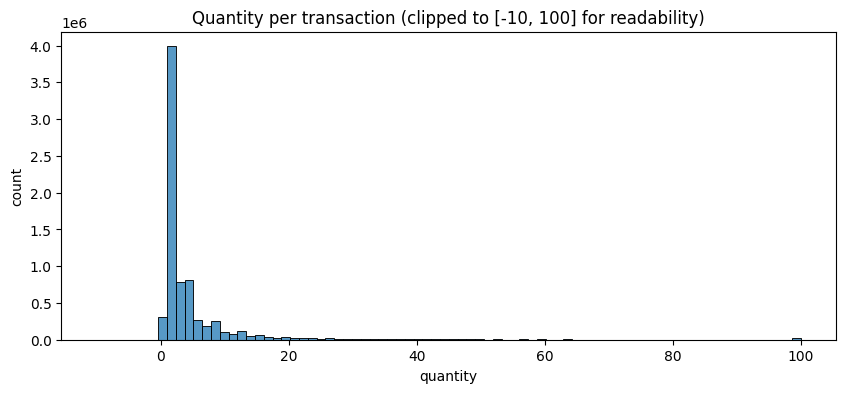

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["quantity"].clip(-10, 100), bins=80, ax=ax)
ax.set_title("Quantity per transaction (clipped to [-10, 100] for readability)")
ax.set_xlabel("quantity"); ax.set_ylabel("count")
plt.show()

## Per-product activity

In [5]:
daily = preprocessing.aggregate_daily(df)
per_item = (daily.groupby("item_id")
                  .agg(days_with_sales=("date", "nunique"),
                       total_qty=("quantity", "sum"))
                  .sort_values("total_qty", ascending=False))
print("days_with_sales distribution:")
print(per_item["days_with_sales"].describe(percentiles=[.5, .9, .99]).round(1))
print()
print("Products with full 761-day history:",
      (per_item["days_with_sales"] >= 761).sum())
per_item.head(10)

days_with_sales distribution:
count    28182.0
mean       175.5
std        216.0
min          1.0
50%         72.0
90%        554.0
99%        759.0
max        761.0
Name: days_with_sales, dtype: float64

Products with full 761-day history: 187


,days_with_sales,total_qty
item_id,,
b0d24502fb66,761,2022732.000
9a7e315f3f42,761,563403.013
63161948a95a,761,434289.000
e5b2b6f57ea7,761,358707.000
0973df3ff57f,761,344912.918
b5aac3497e3f,684,230549.000
6d284b4e9982,761,205106.000
5b8e114fdf6f,564,174563.044
9b4865c6faf1,759,170768.000


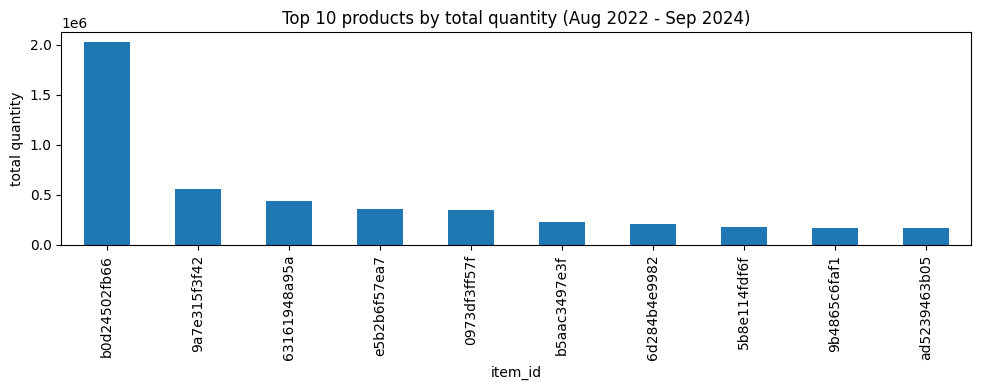

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
per_item.head(10)["total_qty"].plot(kind="bar", ax=ax)
ax.set_title("Top 10 products by total quantity (Aug 2022 - Sep 2024)")
ax.set_ylabel("total quantity"); ax.set_xlabel("item_id")
plt.tight_layout(); plt.show()

## Aggregate daily volume

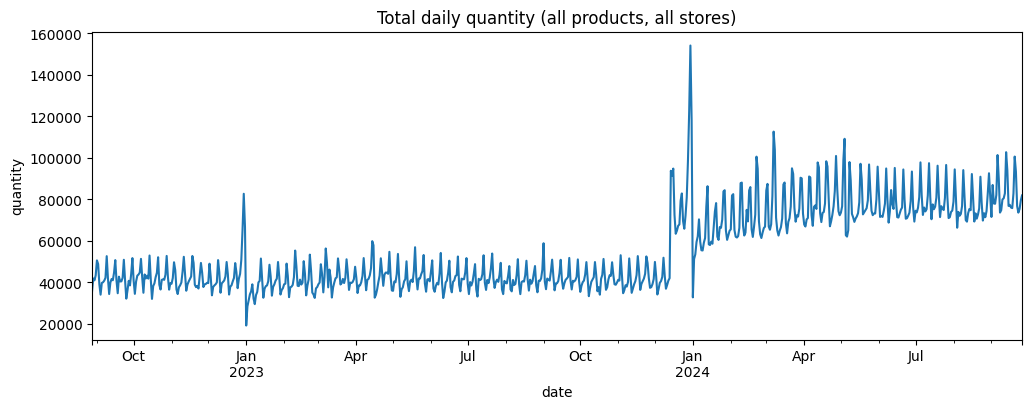

In [7]:
total_daily = daily.groupby("date")["quantity"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
total_daily.plot(ax=ax)
ax.set_title("Total daily quantity (all products, all stores)")
ax.set_ylabel("quantity"); ax.set_xlabel("date")
plt.show()

## Weekly seasonality

C:\Users\PREDTOR\AppData\Local\Temp\ipykernel_2992\3853096261.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])


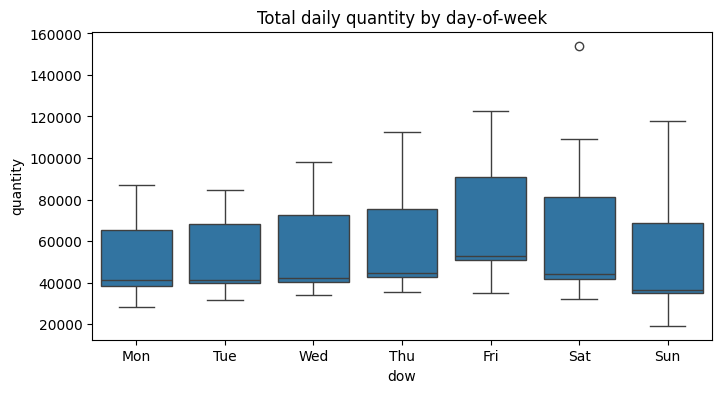

In [8]:
total_daily_df = total_daily.reset_index()
total_daily_df["dow"] = total_daily_df["date"].dt.dayofweek
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=total_daily_df, x="dow", y="quantity", ax=ax)
ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_title("Total daily quantity by day-of-week")
plt.show()

## Store-level breakdown

There are 4 stores. If volume, product mix, or seasonality differ significantly between stores, per-store models (or store as a feature) will outperform a single shared model.

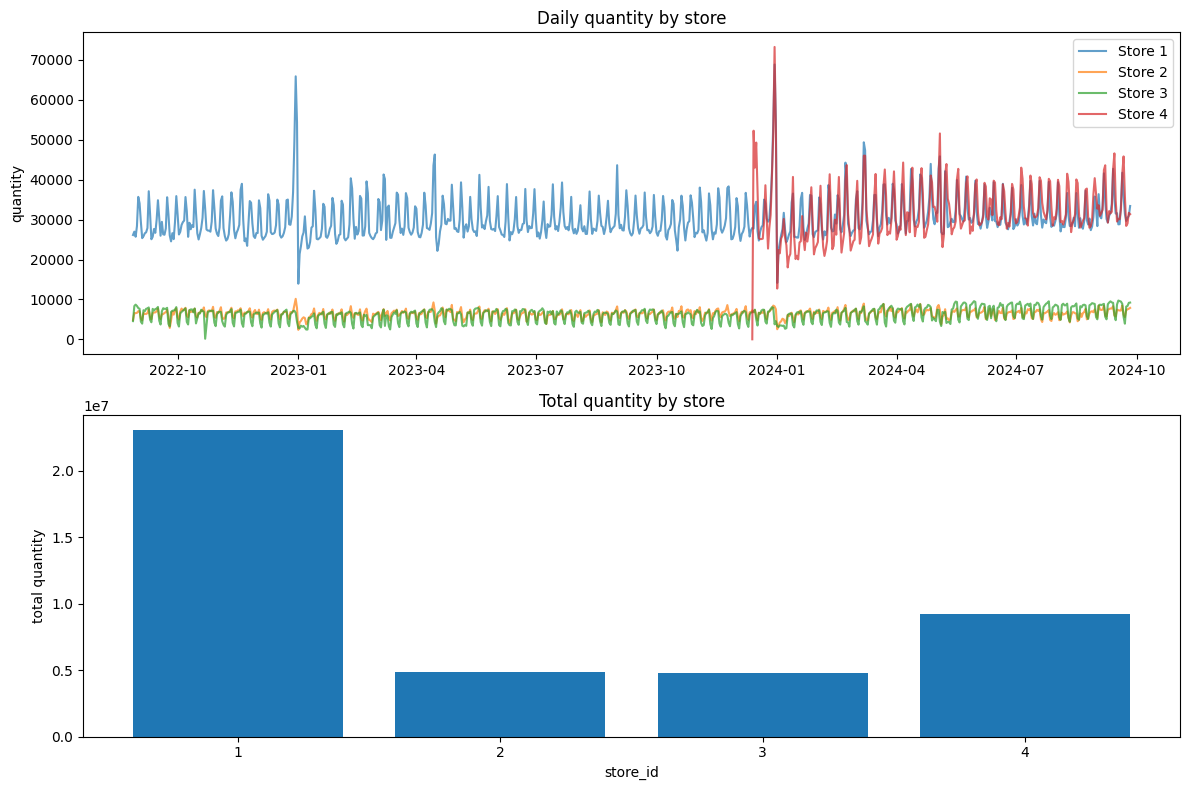


Store summary:
                 sum     mean     std
store_id                             
1         23064331.5  30307.9  5127.9
2          4898827.6   6437.4  1029.2
3          4755147.1   6256.8  1776.4
4          9219859.1  31902.6  7283.3


In [9]:
store_daily = df.groupby(["store_id", "date"])["quantity"].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for sid, grp in store_daily.groupby("store_id"):
    axes[0].plot(grp["date"], grp["quantity"], label=f"Store {sid}", alpha=0.7)
axes[0].set_title("Daily quantity by store")
axes[0].set_ylabel("quantity")
axes[0].legend()

store_totals = store_daily.groupby("store_id")["quantity"].sum()
axes[1].bar(store_totals.index.astype(str), store_totals.values)
axes[1].set_title("Total quantity by store")
axes[1].set_ylabel("total quantity")
axes[1].set_xlabel("store_id")

plt.tight_layout()
plt.show()

print("\nStore summary:")
print(store_daily.groupby("store_id")["quantity"].agg(["sum","mean","std"]).round(1))

## Fractional quantities

Some rows have non-integer quantities (e.g. 0.822 in the sample above). These likely represent weight-based or volume-based products. Understanding their prevalence matters because models for count-based demand behave differently from continuous-value demand.

In [10]:
frac_mask = (df["quantity"] % 1 != 0)
print(f"Fractional-quantity rows : {frac_mask.sum():,} ({100*frac_mask.mean():.2f}%)")
print(f"Distinct items affected  : {df.loc[frac_mask, 'item_id'].nunique():,}")
print("\nSample fractional rows:")
df[frac_mask][["date", "item_id", "quantity", "price_base", "store_id"]].head(10)

Fractional-quantity rows : 829,933 (11.17%)
Distinct items affected  : 2,500

Sample fractional rows:


,date,item_id,quantity,price_base,store_id
2,2023-08-04,daa46ef49b7a,0.822,379.00,1
11,2023-08-04,0aa837b93d7e,46.340,147.55,1
34,2023-08-04,15dc87b629e3,2.824,279.00,1
49,2023-08-04,f18795da117c,3.334,559.00,1
55,2023-08-04,7fee29b0a107,1.610,499.00,1
60,2023-08-04,50b245105c0a,0.474,859.89,1
64,2023-08-04,69731fcfc598,14.424,948.65,1
75,2023-08-04,7df326b32b8c,11.925,346.05,1
80,2023-08-04,13d4259b0f09,3.921,289.90,1
84,2023-08-04,b98a6c55bfe8,3.364,606.48,1


## Missing value analysis

Inspect raw null counts across all columns before any imputation is applied.

In [11]:
missing = df.isna().sum()
pct = (100 * missing / len(df)).round(4)

print("Missing values per column:")
for col in df.columns:
    print(f"  {col}: {missing[col]:,} ({pct[col]:.4f}%)")

print(f"\nRows with at least one missing value: {df.isna().any(axis=1).sum():,}")

Missing values per column:
  date: 0 (0.0000%)
  item_id: 0 (0.0000%)
  quantity: 0 (0.0000%)
  price_base: 0 (0.0000%)
  sum_total: 0 (0.0000%)
  store_id: 0 (0.0000%)

Rows with at least one missing value: 0


## Monthly and yearly seasonality

Weekly patterns are clear; this section checks whether monthly seasonality and year-over-year growth are also present and should be encoded as calendar features.

C:\Users\PREDTOR\AppData\Local\Temp\ipykernel_2992\3851317059.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(month_labels)


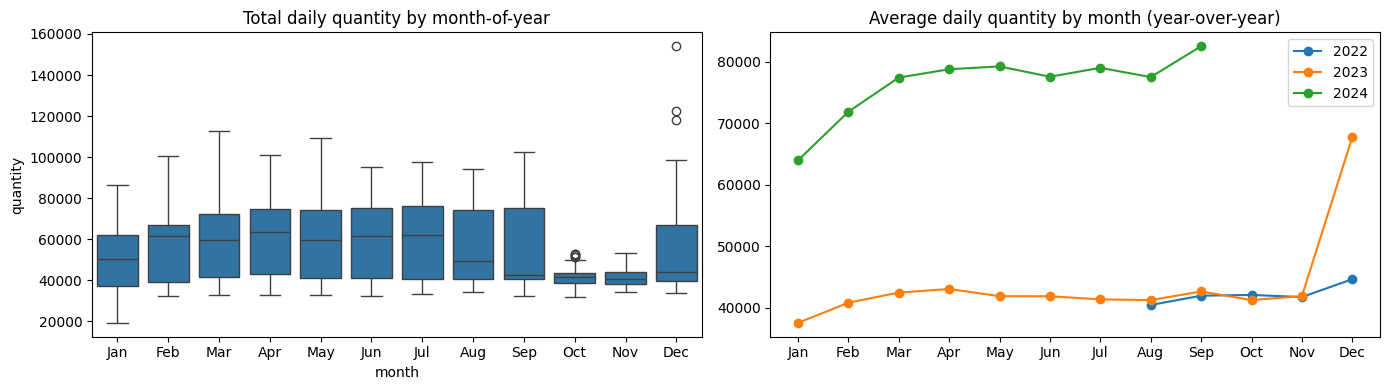

In [12]:
total_daily_df["month"] = total_daily_df["date"].dt.month
total_daily_df["year"] = total_daily_df["date"].dt.year

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=total_daily_df, x="month", y="quantity", ax=axes[0])
axes[0].set_xticklabels(month_labels)
axes[0].set_title("Total daily quantity by month-of-year")

for yr, grp in total_daily_df.groupby("year"):
    grp_monthly = grp.groupby("month")["quantity"].mean()
    axes[1].plot(grp_monthly.index, grp_monthly.values, marker="o", label=str(yr))
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title("Average daily quantity by month (year-over-year)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Autocorrelation (ACF / PACF)

ACF shows the lag structure of the series; PACF isolates direct lag effects. Spikes at multiples of 7 confirm weekly seasonality and inform the choice of lookback window for LSTM/RNN models and lag features for Random Forest.

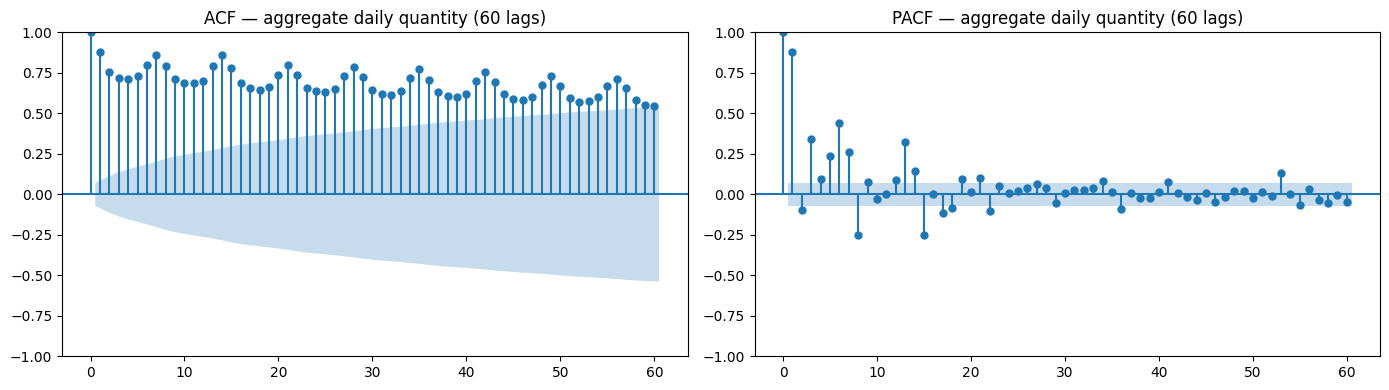

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(total_daily.values, lags=60, ax=axes[0],
         title="ACF — aggregate daily quantity (60 lags)")
plot_pacf(total_daily.values, lags=60, ax=axes[1],
          title="PACF — aggregate daily quantity (60 lags)")
plt.tight_layout()
plt.show()

## Stationarity check (ADF test)

A non-stationary series has a unit root; differencing is required before fitting models that assume stationarity. The ADF null hypothesis is that a unit root is present.

In [14]:
from statsmodels.tsa.stattools import adfuller

series = total_daily.values

result = adfuller(series, autolag="AIC")
print("ADF Stationarity Test — aggregate daily quantity")
print(f"  ADF statistic : {result[0]:.4f}")
print(f"  p-value       : {result[1]:.4f}")
print(f"  lags used     : {result[2]}")
print(f"  n obs         : {result[3]}")
for k, v in result[4].items():
    print(f"  critical value ({k}): {v:.4f}")

if result[1] < 0.05:
    print("\n→ Reject H0: series is likely stationary (no differencing needed).")
else:
    print("\n→ Fail to reject H0: series may be non-stationary — consider differencing.")

ADF Stationarity Test — aggregate daily quantity
  ADF statistic : -0.6567
  p-value       : 0.8576
  lags used     : 20
  n obs         : 740
  critical value (1%): -3.4392
  critical value (5%): -2.8655
  critical value (10%): -2.5689

→ Fail to reject H0: series may be non-stationary — consider differencing.


## STL decomposition

Separates the aggregate series into trend, weekly seasonal, and residual components. The strength scores (0–1) quantify how much of the variance is explained by each component.

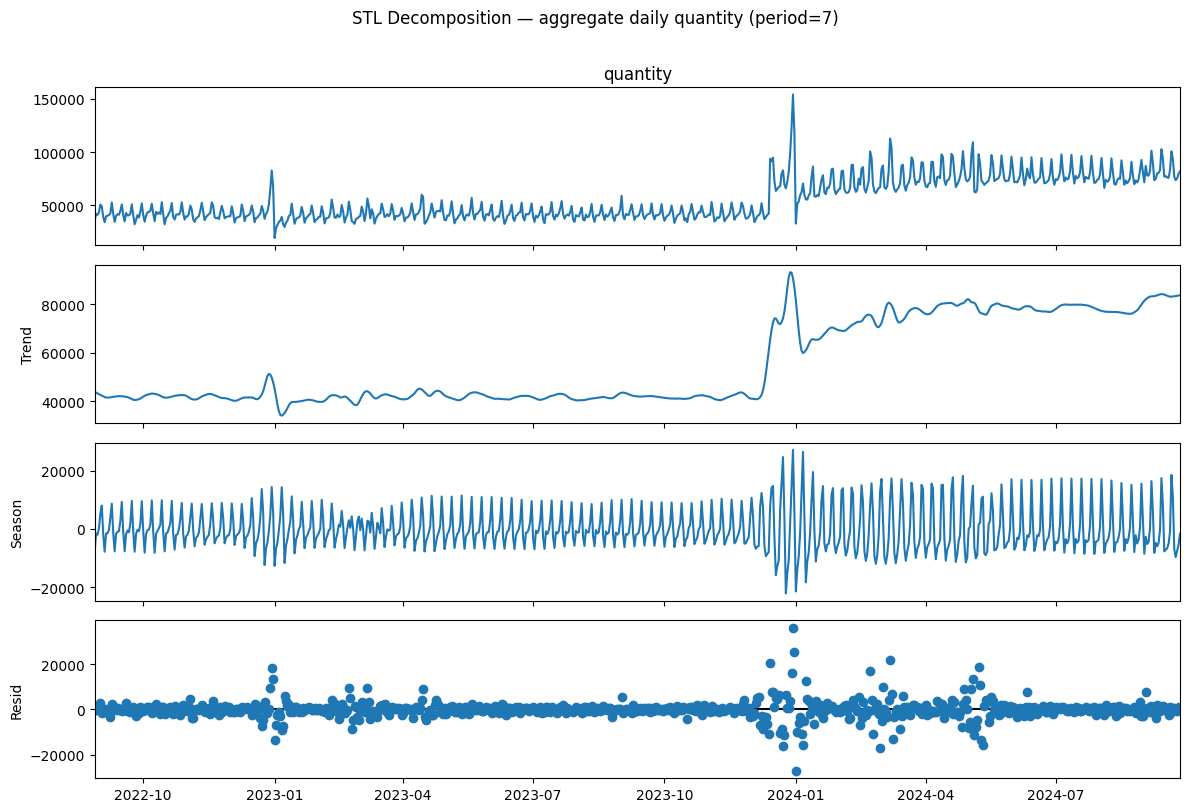

Strength of trend:       0.951  (0=none, 1=strong)
Strength of seasonality: 0.764  (0=none, 1=strong)


In [15]:
from statsmodels.tsa.seasonal import STL

stl = STL(total_daily, period=7)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition — aggregate daily quantity (period=7)", y=1.01)
plt.tight_layout()
plt.show()

var_resid = np.var(res.resid)
var_trend_resid = np.var(res.trend + res.resid)
var_season_resid = np.var(res.seasonal + res.resid)
F_trend = max(0, 1 - var_resid / var_trend_resid)
F_season = max(0, 1 - var_resid / var_season_resid)
print(f"Strength of trend:       {F_trend:.3f}  (0=none, 1=strong)")
print(f"Strength of seasonality: {F_season:.3f}  (0=none, 1=strong)")

## Item-level sample time series

Individual time series for the top-volume items reveal sparsity patterns, volatility, and any item-specific anomalies that aggregate views hide.

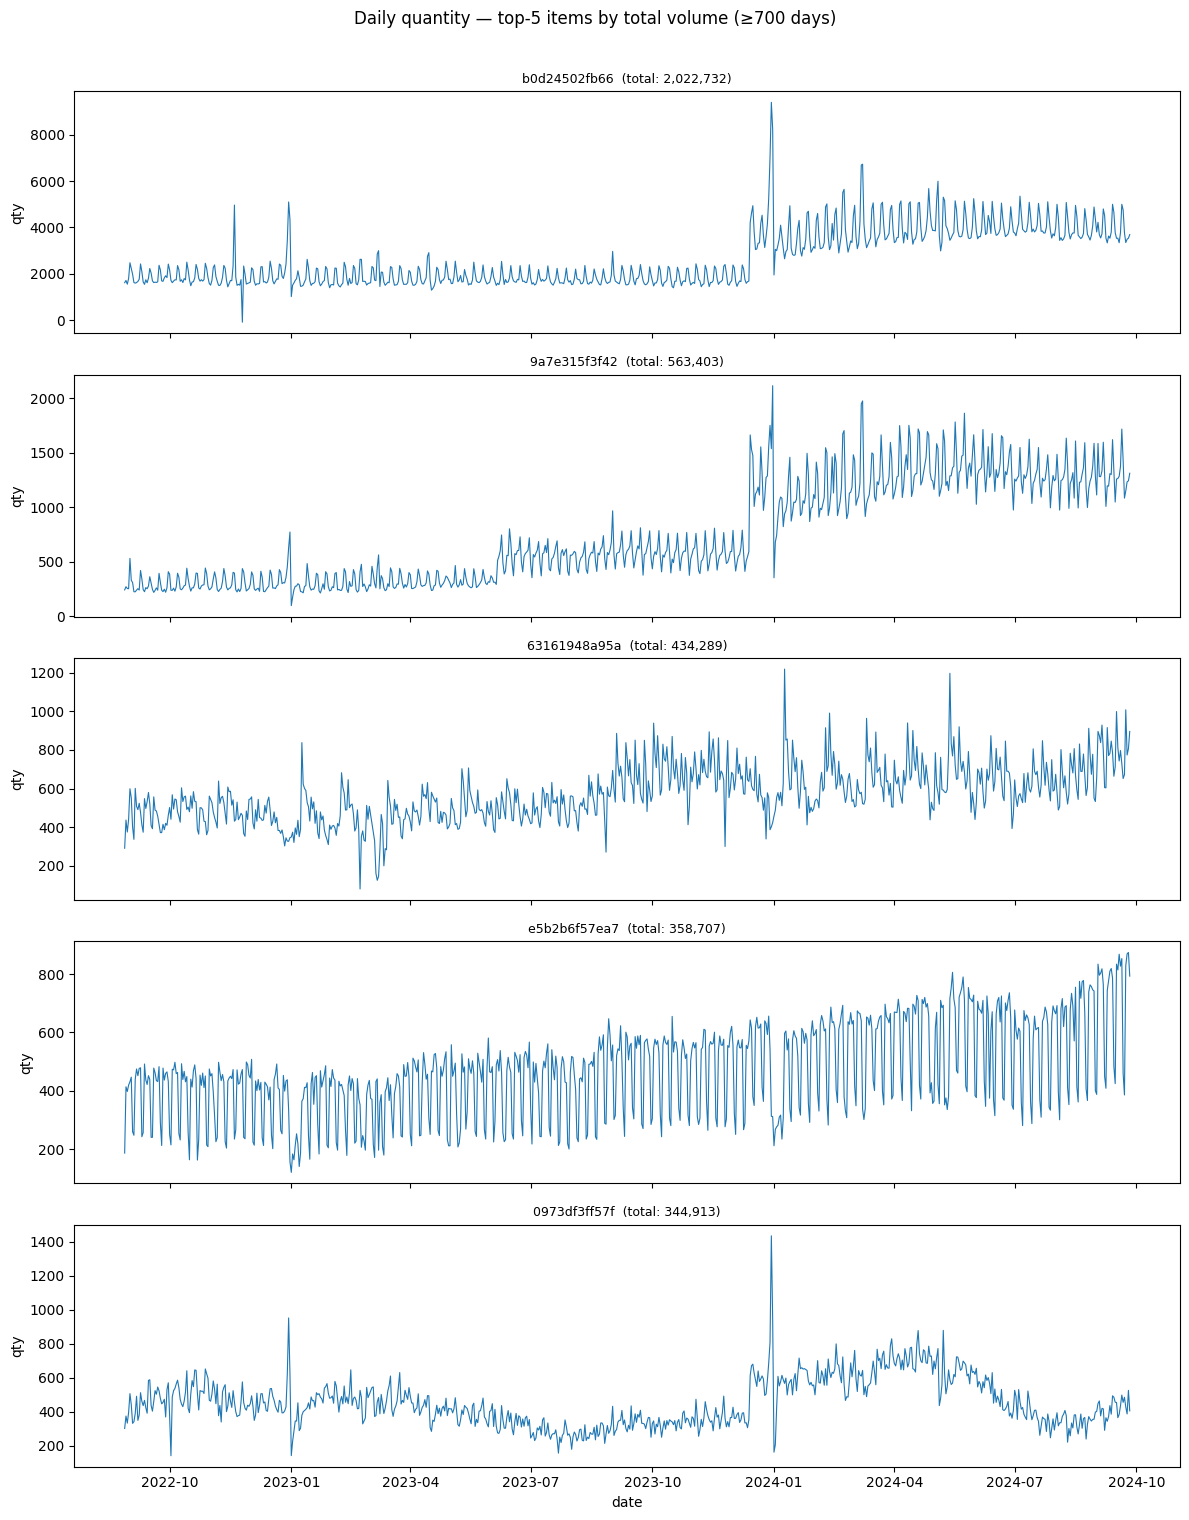

In [16]:
# Pick top-5 items by total quantity with near-full history
top_items = per_item[per_item["days_with_sales"] >= 700].head(5).index.tolist()

fig, axes = plt.subplots(len(top_items), 1, figsize=(12, 3 * len(top_items)), sharex=True)

for ax, item in zip(axes, top_items):
    ts = daily[daily["item_id"] == item].set_index("date")["quantity"].sort_index()
    ax.plot(ts, linewidth=0.8)
    ax.set_title(f"{item}  (total: {ts.sum():,.0f})", fontsize=9)
    ax.set_ylabel("qty")

axes[-1].set_xlabel("date")
fig.suptitle("Daily quantity — top-5 items by total volume (≥700 days)", y=1.01)
plt.tight_layout()
plt.show()

## Key findings used downstream

- **Data**: 761 days (Aug 2022–Sep 2024), ~28k unique items, 4 stores, 7.4M transaction rows.
- **Sparsity**: Median item has only ~72 days of sales; 187 items have the full 761-day history. Only the high-volume head is suitable for a 30-day LSTM/RNN forecast.
- **Returns**: 0.02% of rows have negative quantities — netted into daily totals by `aggregate_daily`.
- **Fractional quantities**: A subset of items sell in non-integer quantities (weight/volume-based); verify whether these need separate treatment from count-based items.
- **Missing flags**: Imputation rates for `price_base`, `sum_total`, `store_id` are quantified above — low rates are acceptable; high rates warrant investigation before using price as a feature.
- **Store heterogeneity**: Volume and variance differ across the 4 stores — include `store_id` as a feature or train per-store models depending on scale.
- **Weekly seasonality**: Clear day-of-week pattern → day-of-week features are essential.
- **Monthly / yearly seasonality**: Check plots above; add month-of-year and year features if patterns are visible.
- **Stationarity**: ADF result above determines whether differencing is required before feeding the series to models.
- **ACF/PACF**: Dominant lags (especially multiples of 7) inform the LSTM lookback window and the lag set for Random Forest.
- **STL**: Trend and seasonal strength scores quantify how much signal each component carries — high seasonal strength validates calendar features; high trend strength may require trend-aware architectures.